# Choice-Only Models in HSSM

Not all behavioral data comes with response times. In questionnaire studies, forced-choice paradigms without time pressure, or when RT is simply not recorded, we only observe **which option** a participant chose. HSSM supports this setting through **choice-only models**.

This tutorial uses the `softmax_inv_temperature` model, which ships with HSSM.

We will:

1. Review the softmax inverse-temperature model and its likelihood
2. Recover known parameters from simulated 2-choice data
3. Add a trial-level covariate that modulates choice
4. Extend to a hierarchical (multi-subject) setting
5. Demonstrate the 3-choice variant

## Colab Instructions

If you would like to run this tutorial on Google Colab, uncomment and run the cell below, then **restart your runtime**.

In [1]:
# If running this on Colab, please uncomment the next line
# !pip install hssm

## Imports

In [2]:
import arviz as az
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.special import softmax

import hssm

hssm.set_floatX("float32", update_jax=True)

Setting PyTensor floatX type to float32.


Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


## The Softmax Inverse-Temperature Model

Consider a task with $K$ choice options. The model has the following parameters:

- $\beta > 0$ — the **inverse temperature**, controlling how deterministic choices are.
- $\ell_1, \dots, \ell_{K-1}$ — **logits** encoding relative preference for each option. The reference option has $\ell_0 = 0$.

The probability of choosing option $k$ is:

$$P(c = k \mid \beta, \boldsymbol{\ell}) = \frac{\exp(\beta \, \ell_k)}{\sum_{j=0}^{K-1} \exp(\beta \, \ell_j)}$$

The log-likelihood for a single trial with observed choice $c_i$ is:

$$\log P(c_i \mid \beta, \boldsymbol{\ell}) = \beta \, \ell_{c_i} - \log \sum_{j=0}^{K-1} \exp(\beta \, \ell_j)$$

**Interpretation:**
- As $\beta \to 0$, choices become **uniform** regardless of logits.
- As $\beta \to \infty$, leads to **deterministically** picking the option with the highest logit.
- Logits encode relative preference: $\ell_k > 0$ means option $k$ is preferred over the reference.

Because only the choice is modeled, the data requires just a single `response` column — no `rt` column is needed. HSSM detects this automatically from the model configuration.

### A Note on Parameter Identifiability

Notice that choice probabilities depend on the **products** $\beta \, \ell_k$, not on $\beta$ and $\ell_k$ individually. For any scalar $c > 0$, the reparameterization $\beta' = c \, \beta$, $\ell_k' = \ell_k / c$ yields identical choice probabilities. This means $\beta$ and the logits are not separately identifiable from choice data alone — only the composite quantities $\beta \, \ell_k$ are.

In practice this manifests as a **ridge in the joint posterior**: $\beta$ and the logits trade off against each other, producing strong negative correlations, slow mixing (low ESS), and posteriors that are wider than one might expect. The pair plots in this tutorial will make this clearly visible.

**Dealing with the tradeoff.** There are several strategies:

1. **Fix $\beta$** (e.g., $\beta = 1$) and let the logits absorb the full scale. This eliminates the redundancy entirely and is the simplest approach when only relative preferences matter.
2. **Use informative priors** on $\beta$ or the logits to constrain the scale.
3. **Add more choices.** With $K \geq 3$ options, $\beta$ must simultaneously scale *all* logits, which partially breaks the degeneracy — the ridge becomes a narrower manifold. Identifiability improves, though correlations remain.
4. **Introduce covariates** that modulate logits across trials. Trial-level variation in the logits constrains $\beta$ more tightly, since $\beta$ acts as a global scaling factor on a varying signal.

We will encounter this tradeoff throughout the tutorial and demonstrate several of these strategies.

## Simulating Choice Data

HSSM's `simulate_data` function is designed for sequential sampling models (which produce both RT and choice). For pure choice data, we define a lightweight simulator below.

In [3]:
def simulate_softmax_data(
    beta,
    logits,
    n_trials,
    choices,
    n_subjects=1,
    rng=None,
):
    """Simulate choice data from a softmax inverse-temperature model.

    Parameters
    ----------
    beta : float or array-like of shape (n_subjects,)
        Inverse temperature.
    logits : list of float or list of arrays of shape (n_subjects,)
        Logits for choices 1..K-1 (logit0 = 0 is implicit).
    n_trials : int
        Trials per subject.
    choices : list
        Choice labels, e.g. [-1, 1] or [0, 1, 2].
    n_subjects : int
        Number of subjects.
    rng : np.random.Generator, optional

    Returns
    -------
    pd.DataFrame with columns 'response' (and 'participant_id' if n_subjects > 1).
    """
    if rng is None:
        rng = np.random.default_rng(2025)

    beta = np.atleast_1d(np.asarray(beta, dtype=float))
    logit_arrays = [np.atleast_1d(np.asarray(l, dtype=float)) for l in logits]

    records = []
    for s in range(n_subjects):
        b = beta[s] if beta.size > 1 else beta[0]
        raw_logits = np.array(
            [0.0] + [l[s] if l.size > 1 else l[0] for l in logit_arrays]
        )
        probs = softmax(b * raw_logits)
        choice_indices = rng.choice(len(choices), size=n_trials, p=probs)
        responses = np.array(choices)[choice_indices]

        df_s = pd.DataFrame({"response": responses})
        if n_subjects > 1:
            df_s["participant_id"] = s
        records.append(df_s)

    return pd.concat(records, ignore_index=True)

### 2-Choice Data (Fixed Parameters)

We generate 500 trials from a binary softmax model with known parameters.

In [4]:
TRUE_BETA_BASIC = 2.0
TRUE_LOGIT1_BASIC = 0.5

data_2c = simulate_softmax_data(
    beta=TRUE_BETA_BASIC,
    logits=[TRUE_LOGIT1_BASIC],
    n_trials=500,
    choices=[-1, 1],
)

data_2c.head()

,response
0,1
1,1
2,1
3,1
4,1


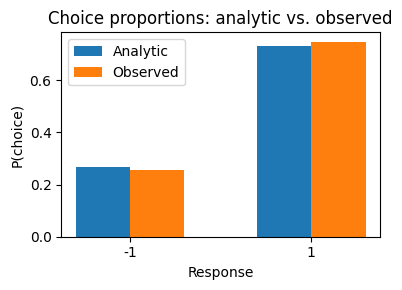

In [5]:
# Sanity check: observed vs. analytic choice proportions
analytic_probs = softmax(TRUE_BETA_BASIC * np.array([0.0, TRUE_LOGIT1_BASIC]))
observed_props = data_2c["response"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(4, 3))
x_pos = np.arange(2)
ax.bar(x_pos - 0.15, analytic_probs, width=0.3, label="Analytic")
ax.bar(x_pos + 0.15, observed_props.values, width=0.3, label="Observed")
ax.set_xticks(x_pos)
ax.set_xticklabels(observed_props.index)
ax.set_ylabel("P(choice)")
ax.set_xlabel("Response")
ax.legend()
ax.set_title("Choice proportions: analytic vs. observed")
plt.tight_layout()
plt.show()

## Model 1: Basic 2-Choice Softmax

We fit the simplest choice-only model. Note how the data only has a `response` column — no `rt`.

In [6]:
model_basic = hssm.HSSM(
    data=data_2c,
    model="softmax_inv_temperature_2",
    loglik_kind="analytical",
)

model_basic

You are building a choice-only model without specifying a RandomVariable class. Using a dummy simulator function. Simulating data from this model will result in an error.


Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: softmax_inv_temperature_2

Response variable: response
Likelihood: analytical
Observations: 500

Parameters:

beta:
    Prior: Gamma(alpha: 2.0, beta: 0.5)
    Explicit bounds: (0.0, inf)

logit1:
    Prior: Normal(mu: 0.0, sigma: 1.0)
    Explicit bounds: (-inf, inf)


Lapse probability: 0.05
Lapse distribution: 0.5

In [7]:
idata_basic = model_basic.sample(
    sampler="numpyro",
    chains=2,
    tune=500,
    draws=500,
)

Using default initvals. 



/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/bambi/backend/pymc.py:224: UserWarning: `init='adapt_diag'` is ignored by `nuts_sampler='numpyro'`; the external sampler uses its own initialization.
  idata = pm.sample(
NUTS[numpyro]: [logit1, beta]


/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:463: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


  0%|          | 0/1000 [00:00<?, ?it/s]

...

sample: 100%|██████████| 1000/1000 [00:00<00:00, 4783.43it/s, 31 steps of size 1.72e-01. acc. prob=0.85]

There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [8]:
az.summary(model_basic.traces)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta,3,1.9,1,6.7,117,122,1.01,0.17,0.19
logit1,0.62,0.37,0.2,1.3,118,112,1.01,0.037,0.035


/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)
/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)
/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 reque

/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)
/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)


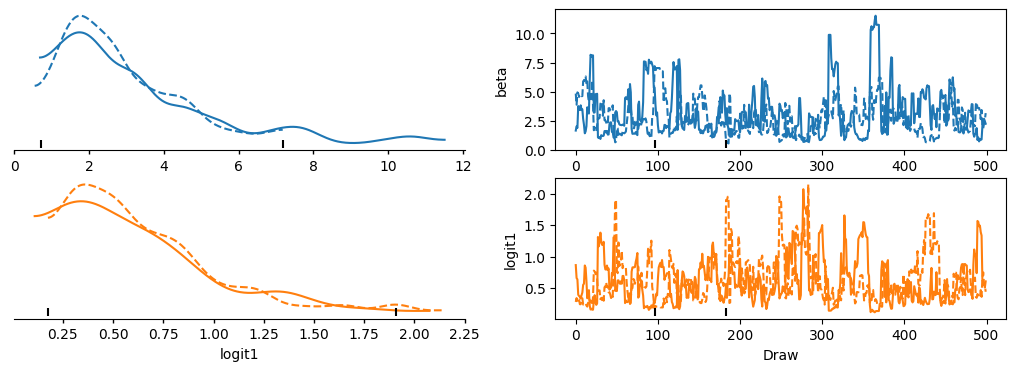

In [9]:
az.plot_trace_dist(idata_basic)

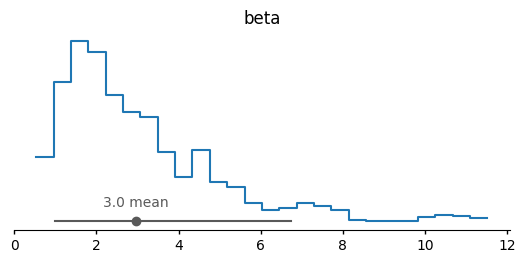

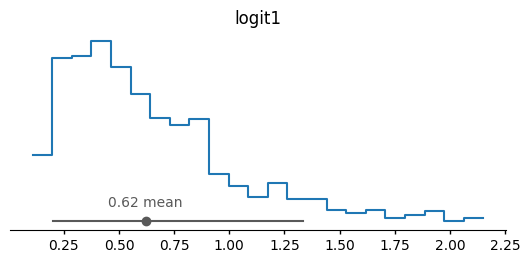

In [10]:
az.plot_dist(
    idata_basic,
    var_names=["beta"],
    kind="hist",
)

az.plot_dist(
    idata_basic,
    var_names=["logit1"],
    kind="hist",
)

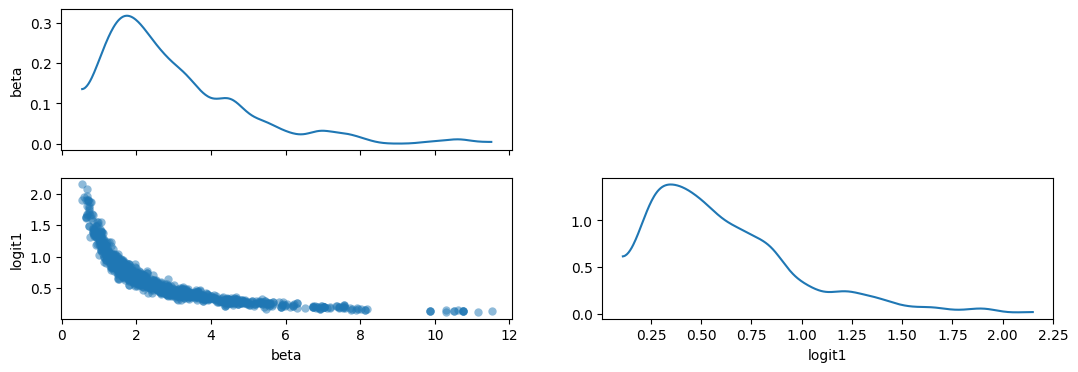

In [11]:
az.plot_pair(idata_basic, var_names=["beta", "logit1"])

### Taking Stock

The posterior concentrates around the true parameter values ($\beta = 2.0$, $\ell_1 = 0.5$), confirming basic parameter recovery. Note that the API is identical to RT-based HSSM models — only the `model` string and the absence of an `rt` column differ.

However, the diagnostics reveal the **$\beta$–logit identifiability tradeoff** discussed in the introduction. The pair plot shows a clear ridge: $\beta$ and $\ell_1$ are negatively correlated, because only their product $\beta \cdot \ell_1$ is identified by the data. This manifests as low ESS, divergences, and posteriors that are wider than one might expect. In the next sections we will see how **covariates** (Model 2), **fixing $\beta$** (Model 3), and **more choices** (Model 4) each help mitigate this issue.

## Model 2: Adding a Covariate

In many experiments, stimulus or task properties modulate choice. Here we simulate a covariate `x` (think: reward difference, stimulus strength) that linearly affects `logit1`:

$$\ell_{1,i} = \alpha + \gamma \, x_i$$

with true values $\alpha = 0.3$ (intercept) and $\gamma = 0.8$ (slope).

In [12]:
TRUE_BETA_REG = 2.0
TRUE_INTERCEPT = 0.3
TRUE_SLOPE = 0.8

rng = np.random.default_rng(42)
n_trials_reg = 1000
x = rng.standard_normal(n_trials_reg)
logit1_trial = TRUE_INTERCEPT + TRUE_SLOPE * x

# Compute trial-wise choice probabilities via softmax
prob_matrix = softmax(
    TRUE_BETA_REG * np.column_stack([np.zeros(n_trials_reg), logit1_trial]),
    axis=1,
)
choices_idx = np.array([rng.choice(2, p=p) for p in prob_matrix])
responses = np.where(choices_idx == 0, -1, 1)

data_reg = pd.DataFrame({"response": responses, "x": x})
data_reg.head()

,response,x
0,1,0.304717
1,-1,-1.039984
2,1,0.750451
3,1,0.940565
4,-1,-1.951035


In [13]:
model_reg = hssm.HSSM(
    data=data_reg,
    model="softmax_inv_temperature_2",
    loglik_kind="analytical",
    include=[{"name": "logit1", "formula": "logit1 ~ x"}],
)

model_reg

You are building a choice-only model without specifying a RandomVariable class. Using a dummy simulator function. Simulating data from this model will result in an error.


Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: softmax_inv_temperature_2

Response variable: response
Likelihood: analytical
Observations: 1000

Parameters:

beta:
    Prior: Gamma(alpha: 2.0, beta: 0.5)
    Explicit bounds: (0.0, inf)

logit1:
    Formula: logit1 ~ x
    Priors:
        logit1_Intercept ~ Normal(mu: 0.0, sigma: 0.25)
        logit1_x ~ Normal(mu: 0.0, sigma: 0.25)
    Link: identity
    Explicit bounds: (-inf, inf)


Lapse probability: 0.05
Lapse distribution: 0.5

In [14]:
idata_reg = model_reg.sample(
    sampler="numpyro",
    chains=2,
    tune=500,
    draws=500,
)

Using default initvals. 



/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/bambi/backend/pymc.py:224: UserWarning: `init='adapt_diag'` is ignored by `nuts_sampler='numpyro'`; the external sampler uses its own initialization.
  idata = pm.sample(
NUTS[numpyro]: [beta, logit1_Intercept, logit1_x]


/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:463: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


  0%|          | 0/1000 [00:00<?, ?it/s]

warmup:   5%|▌         | 50/1000 [00:00<00:05, 175.18it/s, 51 steps of size 1.44e-02. acc. prob=0.74]

...

sample: 100%|██████████| 1000/1000 [00:00<00:00, 2993.98it/s, 11 steps of size 1.36e-01. acc. prob=0.93]


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [15]:
az.summary(idata_reg)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta,5.6,2,3.2,9.3,126,160,1.01,0.18,0.2
logit1_Intercept,0.153,0.052,0.079,0.25,136,164,1.01,0.0045,0.0037
logit1_x,0.37,0.12,0.21,0.58,131,170,1.01,0.011,0.0086


/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)
/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return xp.astype(data, dtype, **kwargs)
/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/xarray/core/duck_array_ops.py:269: UserWarning: Explicitly requested dtype int64 reque

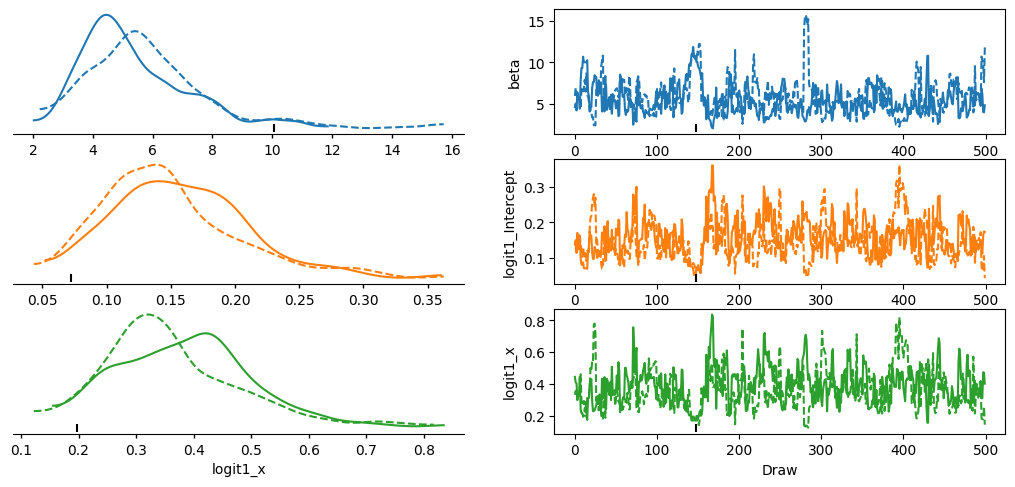

In [16]:
az.plot_trace_dist(idata_reg)

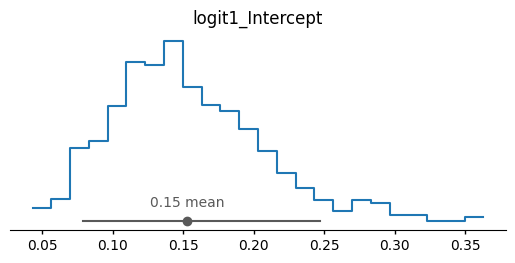

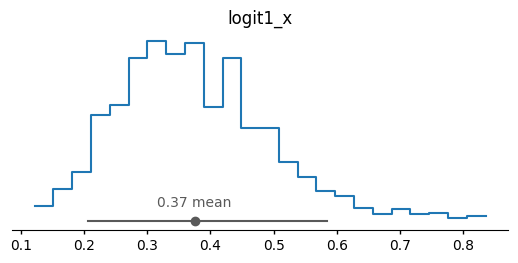

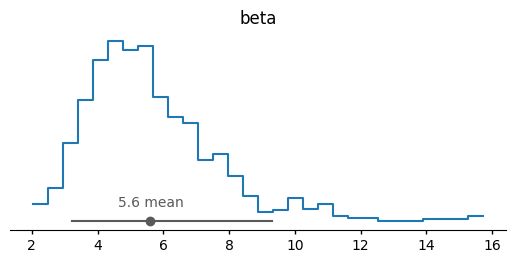

In [17]:
az.plot_dist(
    model_reg.traces,
    var_names=["logit1_Intercept"],
    kind="hist",
)

az.plot_dist(
    model_reg.traces,
    var_names=["logit1_x"],
    kind="hist",
)

az.plot_dist(
    model_reg.traces,
    var_names=["beta"],
    kind="hist",
)

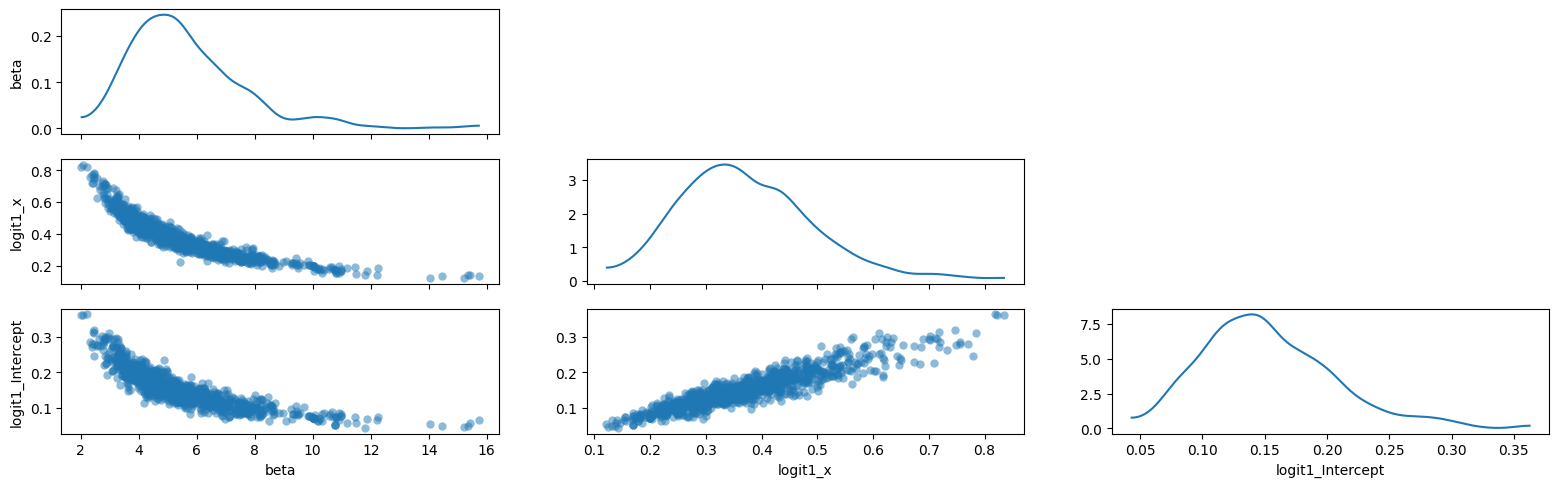

In [18]:
az.plot_pair(model_reg.traces, var_names=["beta", "logit1_x", "logit1_Intercept"])

### Predicted Choice Probability vs. Covariate

We can visualize how the recovered regression translates into choice probability as a function of `x`.

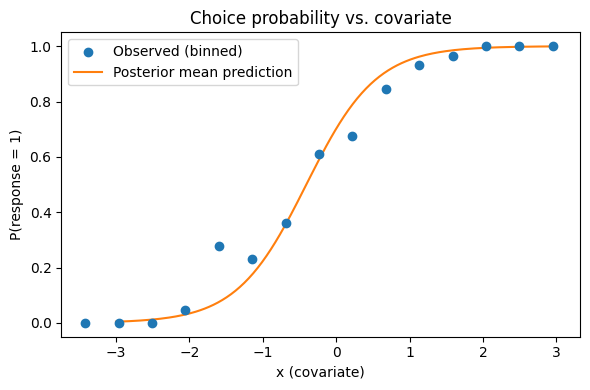

In [19]:
# Posterior mean parameters
post = model_reg.traces.posterior
beta_hat = float(post["beta"].mean())
intercept_hat = float(post["logit1_Intercept"].mean())
slope_hat = float(post["logit1_x"].mean())

# Predicted P(response=1) as a function of x
x_grid = np.linspace(-3, 3, 200)
logit1_grid = intercept_hat + slope_hat * x_grid
p1_grid = softmax(
    beta_hat * np.column_stack([np.zeros_like(x_grid), logit1_grid]),
    axis=1,
)[:, 1]

# Binned observed proportions
data_reg["x_bin"] = pd.cut(data_reg["x"], bins=15)
obs_props = data_reg.groupby("x_bin", observed=True)["response"].apply(
    lambda s: (s == 1).mean()
)
bin_centers = obs_props.index.map(lambda iv: iv.mid)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(bin_centers, obs_props.values, label="Observed (binned)", zorder=3)
ax.plot(x_grid, p1_grid, color="tab:orange", label="Posterior mean prediction")
ax.set_xlabel("x (covariate)")
ax.set_ylabel("P(response = 1)")
ax.legend()
ax.set_title("Choice probability vs. covariate")
plt.tight_layout()
plt.show()

### Taking Stock

The intercept and slope on `logit1` are well recovered, and the predicted choice probability curve tracks the observed data closely. Regression on choice-only model parameters works exactly as for RT-based HSSM models — via the `include` argument.

Notice the identifiability tradeoff at work again: $\beta$ is estimated well above its true value (~5.5 vs. 2.0), while the logit coefficients are proportionally scaled down. This is expected — **covariates help** (strategy 4 from the introduction) by providing trial-level variation that constrains $\beta$, and indeed ESS has improved substantially compared to Model 1. But with $\beta$ still free, the tradeoff persists: the *products* $\beta \cdot \ell_{1,i}$ are what the data actually identify, not $\beta$ and the logit coefficients individually. In the hierarchical model next, we fix $\beta$ to eliminate this redundancy entirely.

## Model 3: Hierarchical (Multi-Subject)

With multiple subjects, we can introduce a hierarchy: subject-level logits are drawn from a shared group distribution, providing regularization.

We simulate 10 subjects (200 trials each), with subject-level $\ell_1^{(s)} \sim \mathcal{N}(0.5, 0.3)$ and a shared $\beta = 2.0$.

In [20]:
TRUE_BETA_HIER = 2.0
TRUE_LOGIT1_MU = 0.5
TRUE_LOGIT1_SD = 0.3
N_SUBJECTS = 20
N_TRIALS_HIER = 200

rng_hier = np.random.default_rng(123)
subject_logit1 = rng_hier.normal(TRUE_LOGIT1_MU, TRUE_LOGIT1_SD, size=N_SUBJECTS)

data_hier = simulate_softmax_data(
    beta=TRUE_BETA_HIER,
    logits=[subject_logit1],
    n_trials=N_TRIALS_HIER,
    choices=[-1, 1],
    n_subjects=N_SUBJECTS,
    rng=rng_hier,
)

print(f"Subject-level logit1 (true): {np.round(subject_logit1, 3)}")
data_hier.head()

Subject-level logit1 (true): [0.203 0.39  0.886 0.558 0.776 0.673 0.309 0.663 0.405 0.403 0.529 0.042
 0.858 0.299 0.8   0.541 0.96  0.302 0.406 0.601]


,response,participant_id
0,-1,0
1,-1,0
2,1,0
3,1,0
4,-1,0


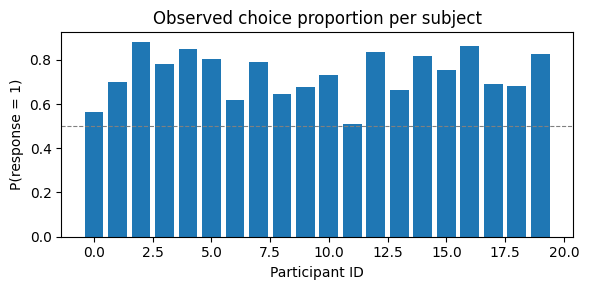

In [21]:
# Quick look: choice proportions per subject
props = data_hier.groupby("participant_id")["response"].apply(lambda s: (s == 1).mean())

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(props.index, props.values)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Participant ID")
ax.set_ylabel("P(response = 1)")
ax.set_title("Observed choice proportion per subject")
plt.tight_layout()
plt.show()

In [22]:
model_hier = hssm.HSSM(
    data=data_hier,
    model="softmax_inv_temperature_2",
    loglik_kind="analytical",
    include=[
        {
            "name": "logit1",
            "formula": "logit1 ~ 1 + (1|participant_id)",
            "prior": {
                "1|participant_id": {
                    "name": "Normal",
                    "mu": 0,
                    "sigma": {
                        "name": "Weibull",
                        "alpha": 1.0,
                        "beta": 1.0,
                    },
                },
                "Intercept": {
                    "name": "Normal",
                    "mu": 0,
                    "sigma": 5.0,
                },
            },
        },
    ],
    beta=TRUE_BETA_HIER,  # Notice we fix this parameter, release it to check for trade-offs
    p_outlier=0.0,
    noncentered=True,
)

model_hier

You are building a choice-only model without specifying a RandomVariable class. Using a dummy simulator function. Simulating data from this model will result in an error.


Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: softmax_inv_temperature_2

Response variable: response
Likelihood: analytical
Observations: 4000

Parameters:

beta:
    Prior: 2.0
    Explicit bounds: (0.0, inf)

logit1:
    Formula: logit1 ~ 1 + (1|participant_id)
    Priors:
        logit1_Intercept ~ Normal(mu: 0.0, sigma: 5.0)
        logit1_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.0, beta: 1.0))
    Link: identity
    Explicit bounds: (-inf, inf)

In [23]:
idata_hier = model_hier.sample(
    sampler="numpyro",
    chains=2,
    tune=1000,
    draws=1000,
)

Using default initvals. 



/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/bambi/backend/pymc.py:224: UserWarning: `init='adapt_diag'` is ignored by `nuts_sampler='numpyro'`; the external sampler uses its own initialization.
  idata = pm.sample(
NUTS[numpyro]: [logit1_Intercept, logit1_1|participant_id_sigma, logit1_1|participant_id_offset]


/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:463: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


  0%|          | 0/2000 [00:00<?, ?it/s]

...

sample:  84%|████████▍ | 1675/2000 [00:01<00:00, 1381.36it/s, 31 steps of size 2.52e-01. acc. prob=0.91]

sample:  91%|█████████ | 1813/2000 [00:01<00:00, 1380.11it/s, 15 steps of size 2.52e-01. acc. prob=0.91]

sample:  97%|█████████▋| 1946/2000 [00:01<00:00, 1364.18it/s, 15 steps of size 2.52e-01. acc. prob=0.91]

sample: 100%|██████████| 2000/2000 [00:01<00:00, 1215.11it/s, 15 steps of size 2.52e-01. acc. prob=0.91]

We recommend running at least 4 chains for robust computation of convergence diagnostics


In [24]:
az.summary(idata_hier)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
logit1_1|participant_id_sigma,0.276,0.052,0.21,0.37,473,665,1.00,0.0024,0.002
logit1_1|participant_id[0],-0.373,0.091,-0.52,-0.22,685,1043,1.00,0.0035,0.0024
logit1_1|participant_id[1],-0.099,0.092,-0.24,0.048,705,942,1.00,0.0035,0.0025
logit1_1|participant_id[2],0.405,0.113,0.23,0.59,1014,1244,1.00,0.0036,0.0025
logit1_1|participant_id[3],0.097,0.1,-0.061,0.26,768,897,1.00,0.0036,0.0028
logit1_1|participant_id[4],0.3,0.108,0.13,0.48,883,1035,1.00,0.0037,0.0026
logit1_1|participant_id[5],0.164,0.102,0.0096,0.33,773,969,1.00,0.0037,0.0027
logit1_1|participant_id[6],-0.267,0.095,-0.42,-0.12,676,858,1.00,0.0036,0.0026
logit1_1|participant_id[7],0.12,0.097,-0.035,0.27,741,945,1.00,0.0035,0.0025
logit1_1|participant_id[8],-0.213,0.089,-0.36,-0.071,630,963,1.00,0.0035,0.0025


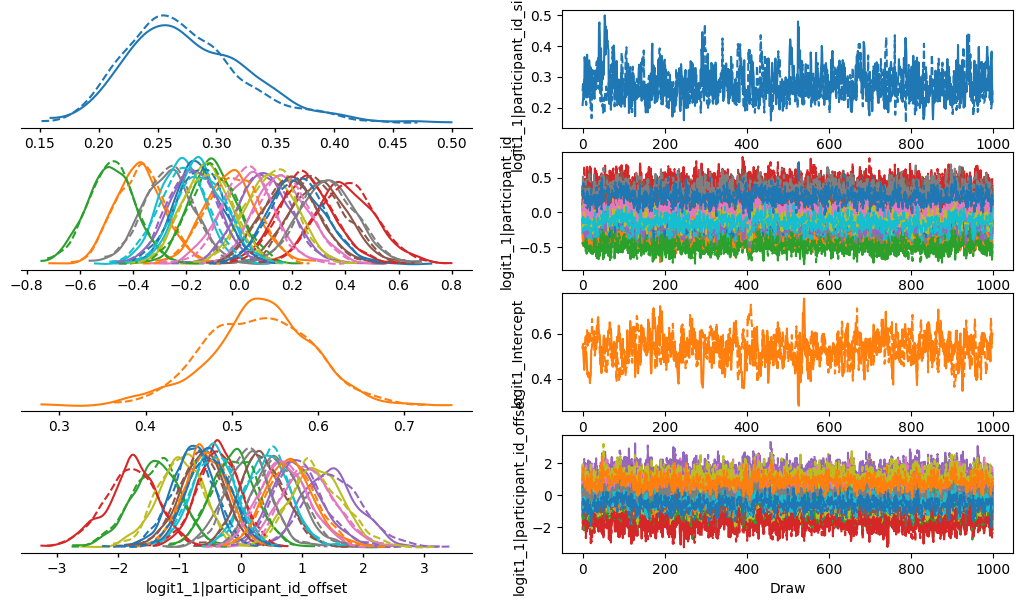

In [25]:
az.plot_trace_dist(idata_hier)

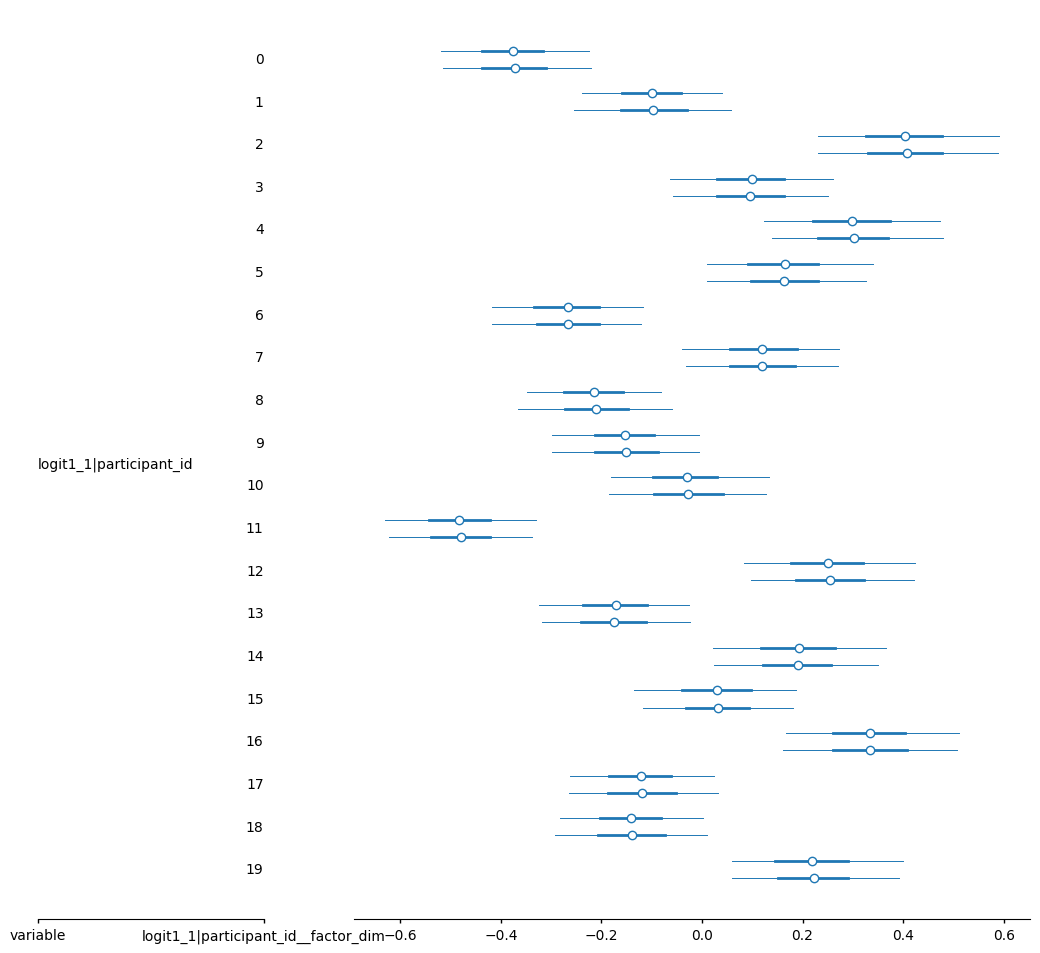

In [26]:
az.plot_forest(idata_hier, var_names=["logit1_1|participant_id"])

### Parameter Recovery: Subject-Level Logits

We compare the recovered subject-level `logit1` offsets against the true values used for simulation.

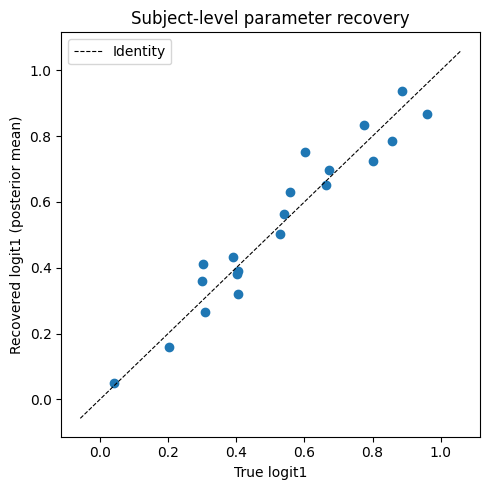

In [27]:
# Extract posterior means for subject-level offsets
post_hier = model_hier.traces.posterior
group_intercept = float(post_hier["logit1_Intercept"].mean())

# Subject offsets from the hierarchical term
subject_offset_vars = [
    v
    for v in post_hier.data_vars
    if "1|participant_id" in v and "sigma" not in v.lower()
]
# The subject-level logit1 = group intercept + subject offset
if len(subject_offset_vars) > 0:
    offsets = post_hier[subject_offset_vars[0]].mean(dim=["chain", "draw"]).values
    recovered_logit1 = group_intercept + offsets
else:
    recovered_logit1 = np.full(N_SUBJECTS, group_intercept)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(subject_logit1, recovered_logit1)
lims = [
    min(subject_logit1.min(), recovered_logit1.min()) - 0.1,
    max(subject_logit1.max(), recovered_logit1.max()) + 0.1,
]
ax.plot(lims, lims, "k--", linewidth=0.8, label="Identity")
ax.set_xlabel("True logit1")
ax.set_ylabel("Recovered logit1 (posterior mean)")
ax.set_title("Subject-level parameter recovery")
ax.legend()
plt.tight_layout()
plt.show()

### Taking Stock

By **fixing $\beta$** to its true value (strategy 1 from the introduction), we completely eliminate the $\beta$–logit tradeoff. The results speak for themselves: no divergences, high ESS across all parameters, $\hat{R} \approx 1.0$, and clean recovery of both the group mean and subject-level logits. Compare this to Models 1 and 2, where $\beta$ was free and the sampler struggled with the resulting ridge in the posterior. When only relative preferences matter and absolute scale is not of interest, fixing $\beta$ is the simplest and most effective strategy.

## Model 4: Extension to 3 Choices

HSSM also ships `softmax_inv_temperature_3` for tasks with three options. The API is identical — just change the model name. With 3 choices we have two logit parameters ($\ell_1$, $\ell_2$), both relative to the reference $\ell_0 = 0$.

In [28]:
TRUE_BETA_3C = 1.5
TRUE_LOGIT1_3C = 0.8
TRUE_LOGIT2_3C = -0.3

data_3c = simulate_softmax_data(
    beta=TRUE_BETA_3C,
    logits=[TRUE_LOGIT1_3C, TRUE_LOGIT2_3C],
    n_trials=800,
    choices=[0, 1, 2],
)

data_3c["response"].value_counts(normalize=True).sort_index()

response
0    0.19250
1    0.67625
2    0.13125
Name: proportion, dtype: float64

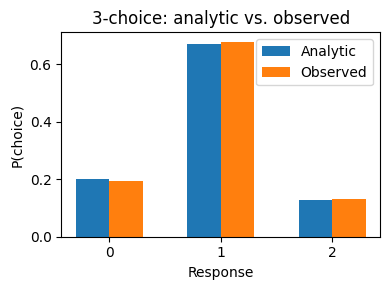

In [29]:
# Analytic check
analytic_3c = softmax(TRUE_BETA_3C * np.array([0.0, TRUE_LOGIT1_3C, TRUE_LOGIT2_3C]))
observed_3c = data_3c["response"].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(4, 3))
x_pos = np.arange(3)
ax.bar(x_pos - 0.15, analytic_3c, width=0.3, label="Analytic")
ax.bar(x_pos + 0.15, observed_3c.values, width=0.3, label="Observed")
ax.set_xticks(x_pos)
ax.set_xticklabels([0, 1, 2])
ax.set_ylabel("P(choice)")
ax.set_xlabel("Response")
ax.legend()
ax.set_title("3-choice: analytic vs. observed")
plt.tight_layout()
plt.show()

In [30]:
model_3c = hssm.HSSM(
    data=data_3c,
    model="softmax_inv_temperature_3",
    loglik_kind="analytical",
)

model_3c

You are building a choice-only model without specifying a RandomVariable class. Using a dummy simulator function. Simulating data from this model will result in an error.


Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: softmax_inv_temperature_3

Response variable: response
Likelihood: analytical
Observations: 800

Parameters:

beta:
    Prior: Gamma(alpha: 2.0, beta: 0.5)
    Explicit bounds: (0.0, inf)

logit1:
    Prior: Normal(mu: 0.0, sigma: 1.0)
    Explicit bounds: (-inf, inf)

logit2:
    Prior: Normal(mu: 0.0, sigma: 1.0)
    Explicit bounds: (-inf, inf)


Lapse probability: 0.05
Lapse distribution: 0.3333333333333333

In [31]:
idata_3c = model_3c.sample(
    sampler="numpyro",
    chains=2,
    tune=500,
    draws=500,
)

Using default initvals. 



/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/bambi/backend/pymc.py:224: UserWarning: `init='adapt_diag'` is ignored by `nuts_sampler='numpyro'`; the external sampler uses its own initialization.
  idata = pm.sample(
NUTS[numpyro]: [logit1, logit2, beta]


/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/Users/yxu150/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:463: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


  0%|          | 0/1000 [00:00<?, ?it/s]

warmup:   5%|▌         | 50/1000 [00:00<00:04, 191.43it/s, 7 steps of size 3.09e-02. acc. prob=0.75]

...

sample:  81%|████████  | 807/1000 [00:00<00:00, 1992.58it/s, 19 steps of size 8.83e-02. acc. prob=0.94]

sample: 100%|██████████| 1000/1000 [00:00<00:00, 1999.46it/s, 47 steps of size 8.83e-02. acc. prob=0.93]

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [32]:
az.summary(model_3c.traces)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta,2.1,1,0.9,3.8,121,192,1.02,0.087,0.076
logit2,-0.39,0.21,-0.8,-0.13,140,225,1.02,0.018,0.016
logit1,0.93,0.44,0.4,1.7,127,204,1.02,0.038,0.034


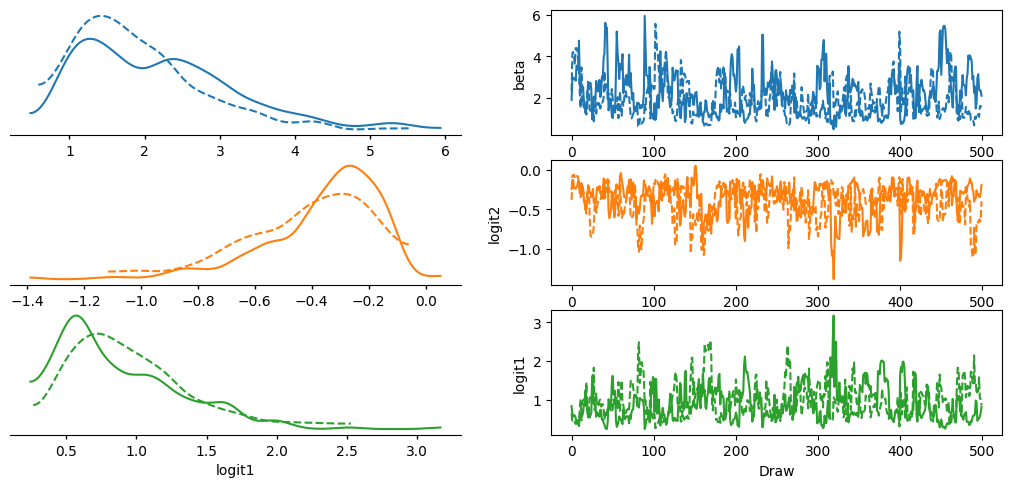

In [33]:
az.plot_trace_dist(idata_3c)

### Taking Stock

The 3-choice model recovers $\beta$, $\ell_1$, and $\ell_2$. The API is unchanged — switching from 2 to 3 choices only requires changing the model string to `"softmax_inv_temperature_3"` and providing data with the appropriate choice labels (`[0, 1, 2]`). Recall that $\ell_0 = 0$ serves as the reference: all estimated logits are relative to option 0.

With $K = 3$ choices, $\beta$ must simultaneously scale *two* logits, which partially breaks the scale degeneracy (strategy 3 from the introduction). Notice that ESS and convergence diagnostics are somewhat improved compared to the 2-choice Model 1, though correlations between $\beta$ and the logits remain. For best results in practice, consider combining multiple strategies — e.g., fixing $\beta$ or using informative priors alongside the richer signal from multiple choice options.

### Related Tutorials

- [Main Tutorial](https://lnccbrown.github.io/HSSM/tutorials/main_tutorial/) — full HSSM workflow with RT-based models
- [Scientific Workflow](https://lnccbrown.github.io/HSSM/tutorials/scientific_workflow_hssm/) — iterative model building with real data
- [RLSSM Basic Tutorial](https://lnccbrown.github.io/HSSM/tutorials/rlssm_basic/) — reinforcement learning sequential sampling models in HSSM